In [1]:
import pandas as pd 
import numpy as np 

## Data Loading

In [2]:
train_df = pd.read_csv(r"D:\PERSONAL PROJECTS\fraud_detection\dataset\fraudTrain.csv")
test_df = pd.read_csv(r"D:\PERSONAL PROJECTS\fraud_detection\dataset\fraudTest.csv")

In [3]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
test_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

## Checking for Duplicate and Missing Values

In [7]:
train_df.duplicated().sum()

np.int64(0)

In [8]:
test_df.duplicated().sum()

np.int64(0)

In [9]:
train_df.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [10]:
test_df.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## EDA

In [11]:
train_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [12]:
test_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [13]:
train_df['unix_time'].unique().sum()

np.int64(1720031497915272)

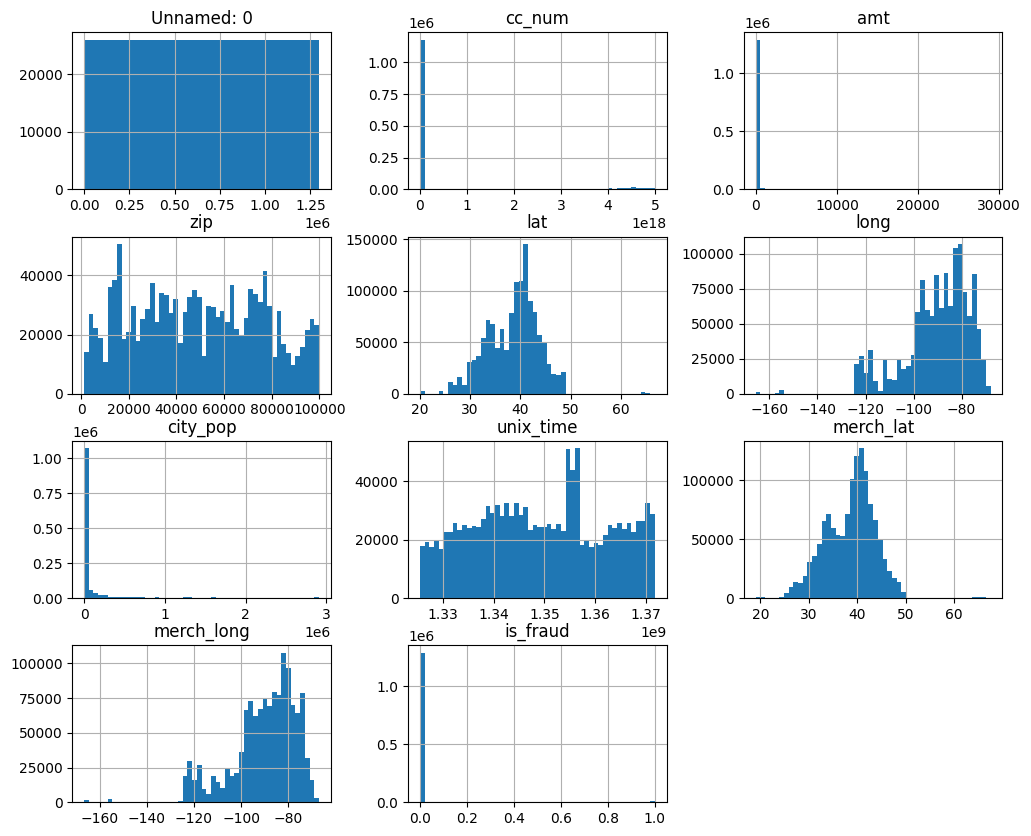

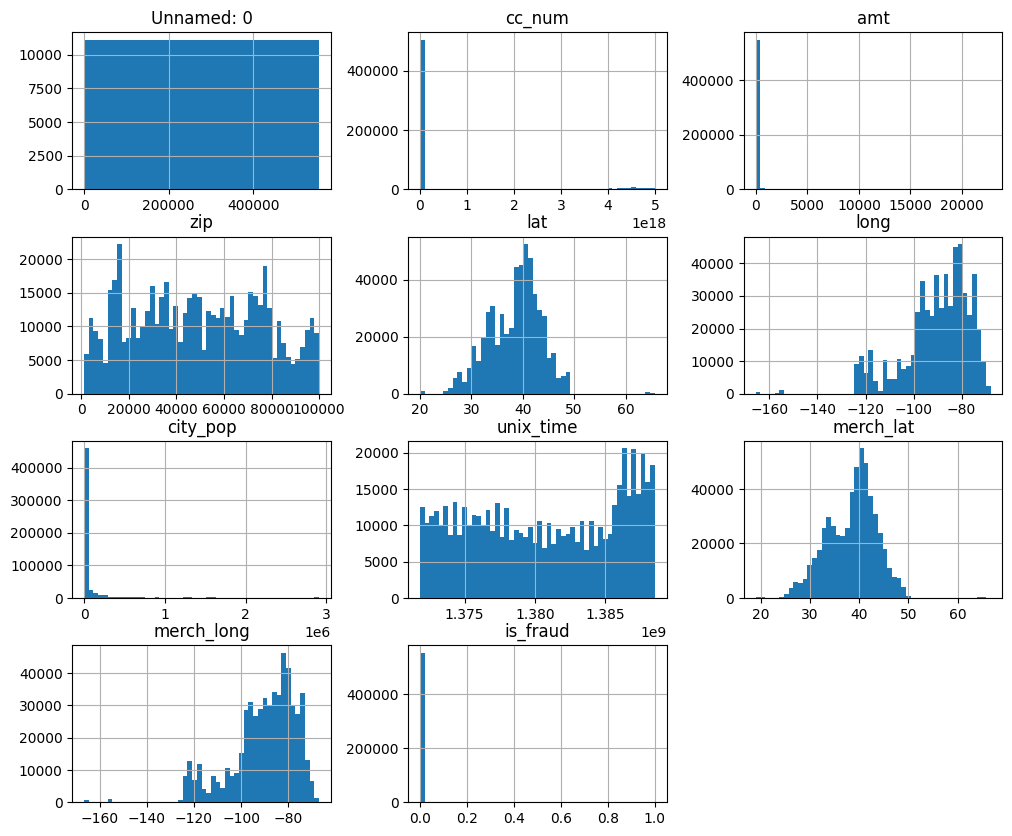

In [14]:
import matplotlib.pyplot as plt

train_df.hist(bins=50,figsize=(12,10))
test_df.hist(bins=50 , figsize=(12,10))
plt.show()


## Outliers Detection

In [15]:
l = []
train_df.columns.append(l)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [16]:
train_cleaned = train_df.copy()
test_cleaned = test_df.copy()

train_bounds = {}

for col in l:
    if train_df[col].dtype in ['int64','float64']:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 + 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        train_bounds[col] = {"lower" : lower_bound , "upper" : upper_bound}

for col in l:
    if col in train_bounds:
        lower = train_bounds[col]["lower"]
        upper = train_bounds[col]["upper"]

        train_cleaned[col] = np.clip(train_cleaned[col] , lower,upper)
        test_cleaned[col] = np.clip(test_cleaned[col] , lower, upper)

print("Outliers have been detected and cleaned. Row counts are preserved")
print(f" Train rows: {len(train_cleaned)} | test rows: {len(test_cleaned)}")

Outliers have been detected and cleaned. Row counts are preserved
 Train rows: 1296675 | test rows: 555719


## Visualization

In [17]:
train_cleaned.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


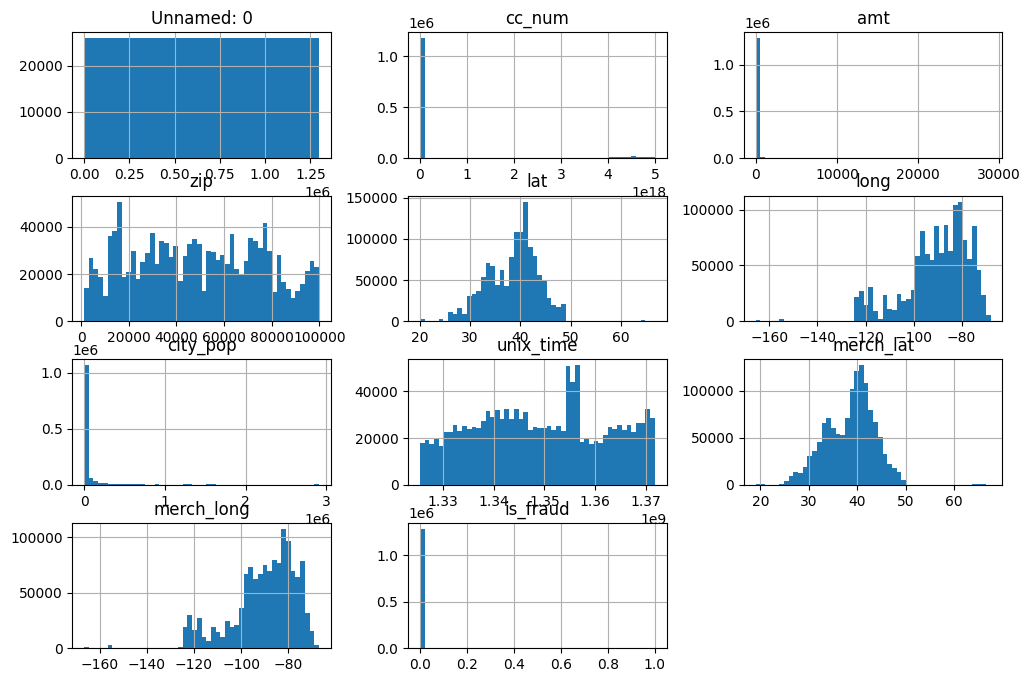

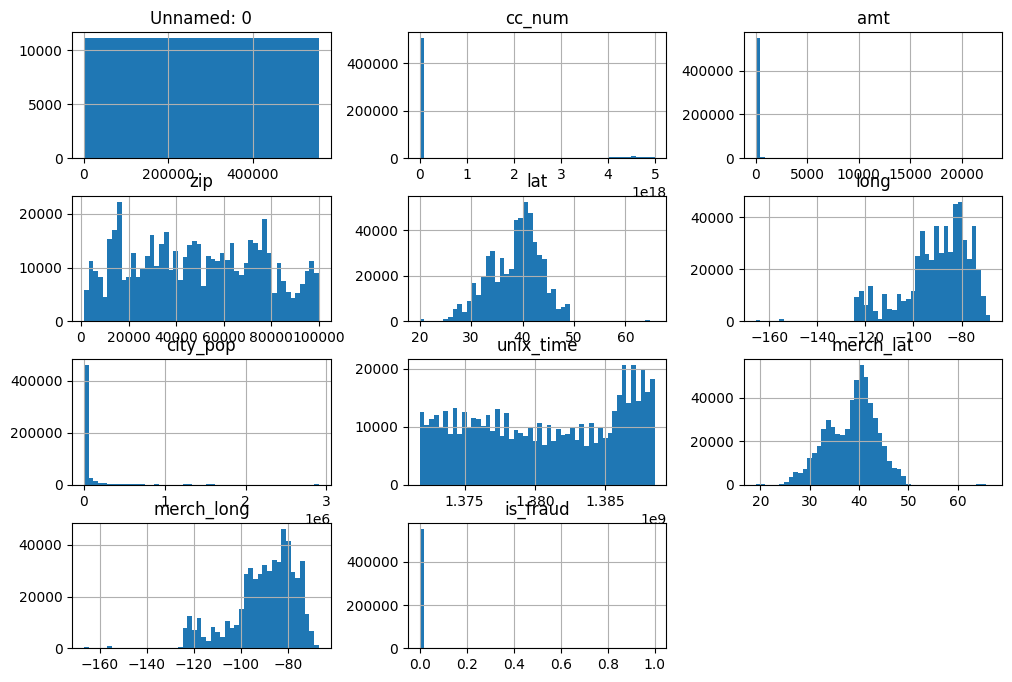

In [18]:
train_cleaned.hist(figsize=(12,8), bins=50)
test_cleaned.hist(bins=50 , figsize=(12,8))

plt.show()

In [19]:
train_cleaned.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

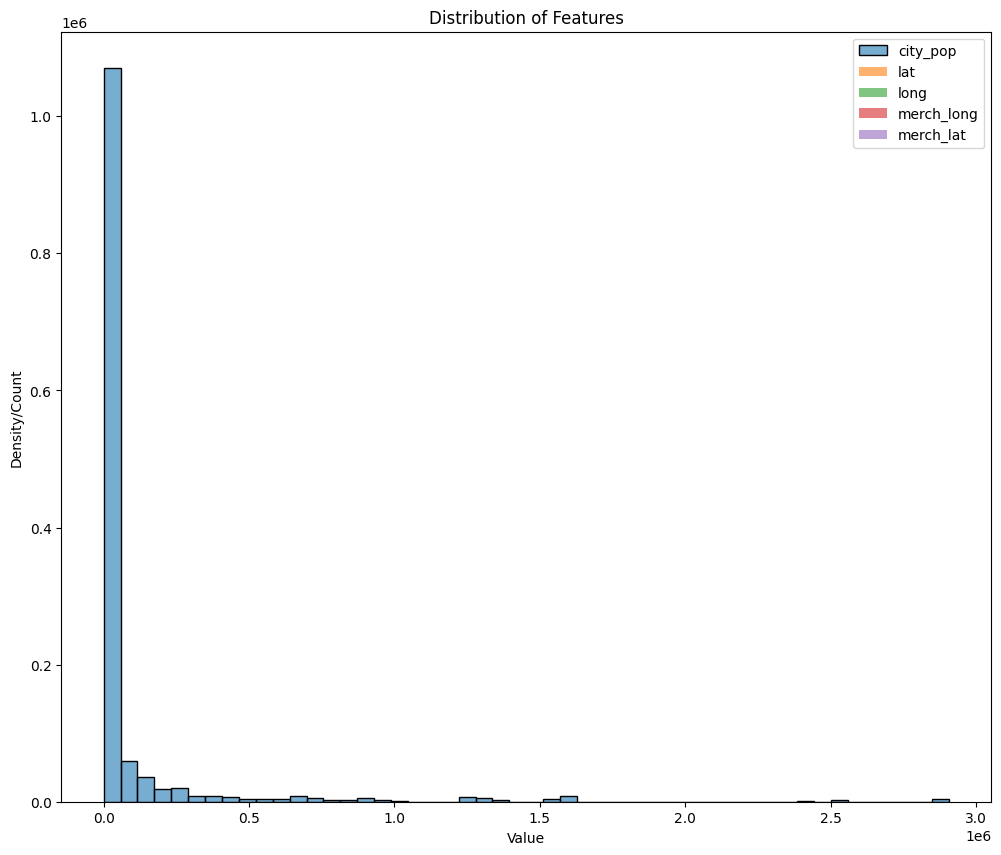

In [20]:
import seaborn as sns

plt.figure(figsize=(12,10))

for i in ['city_pop',  'lat','long','merch_long','merch_lat']:
    sns.histplot(train_cleaned[i] , bins=50 , alpha = 0.6, label=i)

plt.title('Distribution of Features')
plt.xlabel('Value')
plt.ylabel('Density/Count')
plt.legend()
plt.show()

c:\Users\SOURASISH\tf_env\lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


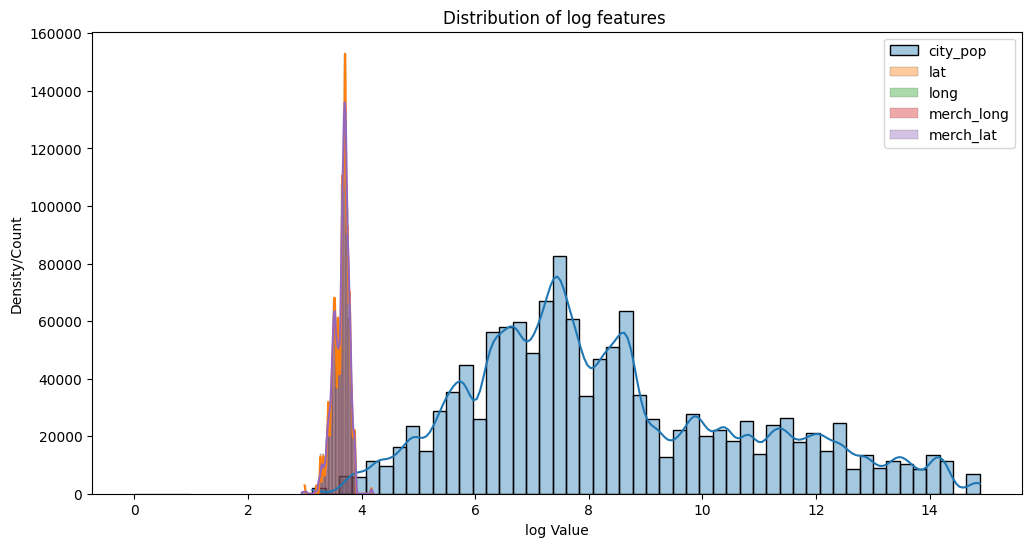

In [21]:
train_df_03= train_cleaned.copy()

train_df_03[['city_pop',  'lat','long','merch_long','merch_lat']] = np.log(train_df_03[['city_pop',  'lat','long','merch_long','merch_lat']])
plt.figure(figsize=(12,6))

for i in ['city_pop',  'lat','long','merch_long','merch_lat']:
    sns.histplot(train_df_03[i],label=i, bins=50,kde=True, alpha=0.4)

plt.title('Distribution of log features ')
plt.xlabel('log Value')
plt.ylabel('Density/Count')
plt.legend()
plt.show()

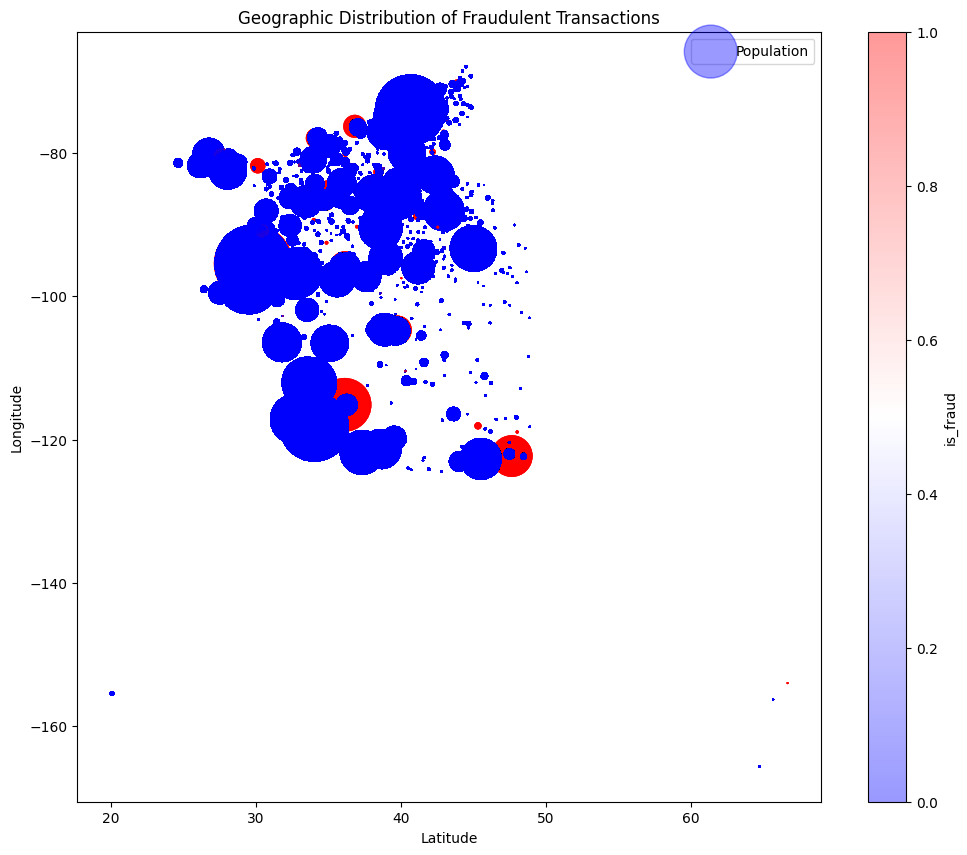

In [22]:
train_cleaned.plot(
    kind='scatter',
    x='lat',
    y='long',
    alpha = 0.4,  # for Transparency
    s = train_cleaned['city_pop']/1000,  # Size, for scaling down the size
    label= 'Population',
    c='is_fraud',  # color code that maps to 'is_fraud' column
    cmap = 'bwr',
    colorbar=True,
    figsize= (12,10)
)

plt.title('Geographic Distribution of Fraudulent Transactions')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

In [23]:
train_cleaned.select_dtypes(include='object').columns

Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')

## Feature Engineering

In [24]:
train_cleaned.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

def calculate_haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def extract_standalone_features(df):
    df = df.copy()
    # Temporal
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Demographic & Geographic
    df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year
    df['dist_km'] = calculate_haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    return df

def extract_behavioral_features(train_df, test_df):
    train_df['is_test'], test_df['is_test'] = 0, 1
    combined = pd.concat([train_df, test_df], ignore_index=True)
    
    # Sort by user, then time
    combined = combined.sort_values(by=['cc_num', 'trans_date_trans_time'])
    
    # Velocity & Frequency
    combined['avg_amt_last_5'] = combined.groupby('cc_num')['amt'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    combined['user_hist_avg'] = combined.groupby('cc_num')['amt'].transform(lambda x: x.expanding().mean())
    combined['amt_ratio'] = combined['amt'] / (combined['user_hist_avg'] + 1e-6)
    
    #  Merchant-level features: MUST sort purely by time for .rolling('24h') to work
    combined = combined.sort_values(by='trans_date_trans_time')
    
    combined = combined.set_index('trans_date_trans_time')
    combined['merch_freq_24h'] = combined.groupby('merchant')['cc_num'].transform(lambda x: x.rolling('24h').count())
    combined = combined.reset_index()
    
    train_res = combined[combined['is_test'] == 0].drop(columns=['is_test', 'user_hist_avg'])
    test_res = combined[combined['is_test'] == 1].drop(columns=['is_test', 'user_hist_avg'])
    return train_res, test_res

def encode_and_scale(train_df, test_df):
    train_df, test_df = train_df.copy(), test_df.copy()
    
    # Categoricals Encoding
    cat_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train_df[cat_cols] = encoder.fit_transform(train_df[cat_cols])
    test_df[cat_cols] = encoder.transform(test_df[cat_cols])
    
    # Numerical Scaling
    num_cols = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 
                'age', 'dist_km', 'avg_amt_last_5', 'amt_ratio', 'merch_freq_24h']
    scaler = StandardScaler()
    train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
    test_df[num_cols] = scaler.transform(test_df[num_cols])
    
    return train_df, test_df, encoder, scaler



print("1. Standalone Features...")
train_df = extract_standalone_features(train_cleaned)
test_df = extract_standalone_features(test_cleaned)

print("2. Behavioral Features...")
train_df, test_df = extract_behavioral_features(train_df, test_df)

print("3. Dropping Raw Columns...")

drop_cols = ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'first', 'last', 
             'street', 'zip', 'dob', 'trans_num', 'unix_time']
train_df = train_df.drop(columns=drop_cols, errors='ignore')
test_df = test_df.drop(columns=drop_cols, errors='ignore')


y_train = train_df.pop('is_fraud')
y_test = test_df.pop('is_fraud')

print("4. Encoding & Scaling...")
X_train, X_test, encoder, scaler = encode_and_scale(train_df, test_df)


joblib.dump(encoder, "../model/encoder.pkl")
joblib.dump(scaler, "../model/scaler.pkl")



1. Standalone Features...
2. Behavioral Features...
3. Dropping Raw Columns...
4. Encoding & Scaling...


['../model/scaler.pkl']

In [26]:
%pip install "xgboost<3.0.0"


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate


pos_weight = int((len(y_train) - sum(y_train)) / sum(y_train))

models = {
   
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1),
    
    
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1),
    
    
    "XGBoost": XGBClassifier(scale_pos_weight=pos_weight, random_state=42, tree_method='hist', n_jobs=-1)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = ['f1', 'roc_auc', 'precision', 'recall']

print("--- Running 3-Fold Stratified Cross-Validation ---")
for name, model in models.items():
    print(f"Training {name} (This may take a minute)...")
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    print(f"\nModel: {name}")
    print(f"  Mean F1-Score:  {scores['test_f1'].mean():.4f}")
    print(f"  Mean ROC-AUC:   {scores['test_roc_auc'].mean():.4f}")
    print(f"  Mean Recall:    {scores['test_recall'].mean():.4f}\n")

--- Running 3-Fold Stratified Cross-Validation ---
Training Logistic Regression (This may take a minute)...

Model: Logistic Regression
  Mean F1-Score:  0.2101
  Mean ROC-AUC:   0.9669
  Mean Recall:    0.8868

Training Random Forest (This may take a minute)...

Model: Random Forest
  Mean F1-Score:  0.7372
  Mean ROC-AUC:   0.9968
  Mean Recall:    0.9106

Training XGBoost (This may take a minute)...

Model: XGBoost
  Mean F1-Score:  0.8679
  Mean ROC-AUC:   0.9992
  Mean Recall:    0.9575



In [28]:
%pip install --upgrade shap

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: shap in c:\users\sourasish\tf_env\lib\site-packages (0.49.1)




[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\SOURASISH\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training Final XGBoost Model ---

 Final Test Set Evaluation ---
              precision    recall  f1-score   support

           0     0.9998    0.9981    0.9989    553574
           1     0.6589    0.9385    0.7742      2145

    accuracy                         0.9979    555719
   macro avg     0.8293    0.9683    0.8866    555719
weighted avg     0.9984    0.9979    0.9981    555719

 SHAP Explanations :


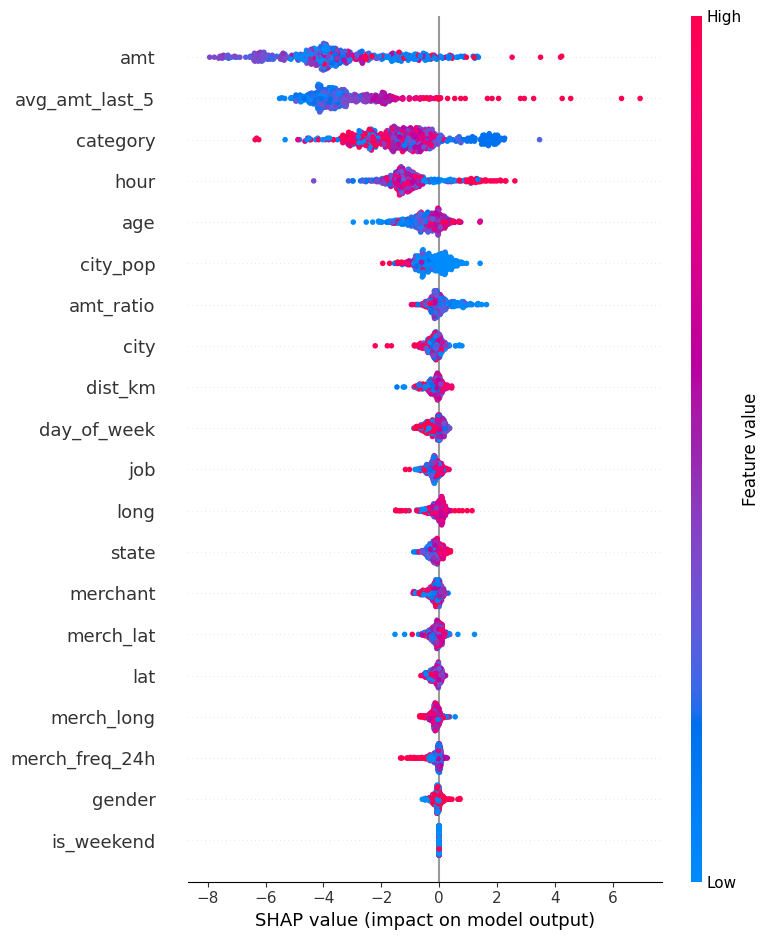

Successfully exported winning model, encoder, and scaler to the /model directory!


In [29]:
import joblib
import shap
import os
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


best_model = XGBClassifier(
    scale_pos_weight=int((len(y_train) - sum(y_train)) / sum(y_train)),
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

print("Training Final XGBoost Model ---")
best_model.fit(X_train, y_train)


print("\n Final Test Set Evaluation ---")
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))


print(" SHAP Explanations :")
explainer = shap.TreeExplainer(best_model)


X_sample = X_train.sample(n=500, random_state=42)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample)


os.makedirs('../model', exist_ok=True)
joblib.dump(best_model, "../model/best_model.pkl")
joblib.dump(encoder, "../model/encoder.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

print("Successfully exported winning model, encoder, and scaler to the /model directory!")

## What is SHAP?
SHAP (SHapley Additive exPlanations) is a mathematical framework based on cooperative game theory. Think of your machine learning model as a "team" and your features (amt, age, dist_km) as the "players." SHAP calculates the exact credit (or blame) each player deserves for the final score of a match.

Instead of just telling what the model predicted, SHAP explains why it made that choice.


1. Feature Importance (Vertical Order)
Features are sorted from top to bottom based on their predictive power.

**amt** (the current transaction amount) and **avg_amt_last_5** (your engineered feature!) are at the very top. This proves that your feature engineering worked beautifully—they are the two most dominant drivers of fraud in your entire system.

2. The Baseline & Impact (The X-Axis)
The center line represents 0.

Any dot to the right of 0 (Positive SHAP values) is pushing the model closer to predicting Fraud (Class 1).

Any dot to the left of 0 (Negative SHAP values) is pulling the model closer to predicting Normal (Class 0).

3. Feature Values (The Colors)
The color bar on the right dictates the actual value of a feature for that specific dot.

Red = High value (e.g., massive transaction amount, older age).

Blue = Low value (e.g., small transaction amount, young age).

### Translating the Key Features
Let's read the top rows of image_93c885.png like a narrative:

* **amt** (Row 1): Look at the right side of the 0-line; there is a spread of bright red dots. This tells us that high transaction amounts significantly push the model's output toward a fraud prediction. Conversely, the dense cluster of blue dots on the far left means low amounts strongly signal legitimate behavior.

* **avg_amt_last_5** (Row 2): Look at the right side of the 0-line—it is a long trail of bright red dots. This tells the model: "If this user's average spending over their last 5 transactions has suddenly spiked significantly, the risk of fraud sky-rockets." This is your engineered velocity feature doing exactly what it was designed to do!

* **category** (Row 3): The distinct grouping of blue dots on the left and mixed red/blue patterns in the middle indicate that specific transaction categories (which were encoded as integers) strongly suppress or alter fraud probability depending on the purchase type (e.g., online shopping vs. grocery stores).

* **hour** (Row 4): Notice the cluster of bright red dots extending to the right. This means high values for hour (late-night hours like 11 PM to 4 AM) increase the likelihood of a transaction being flagged as fraud.

## Explanatory Visualisation

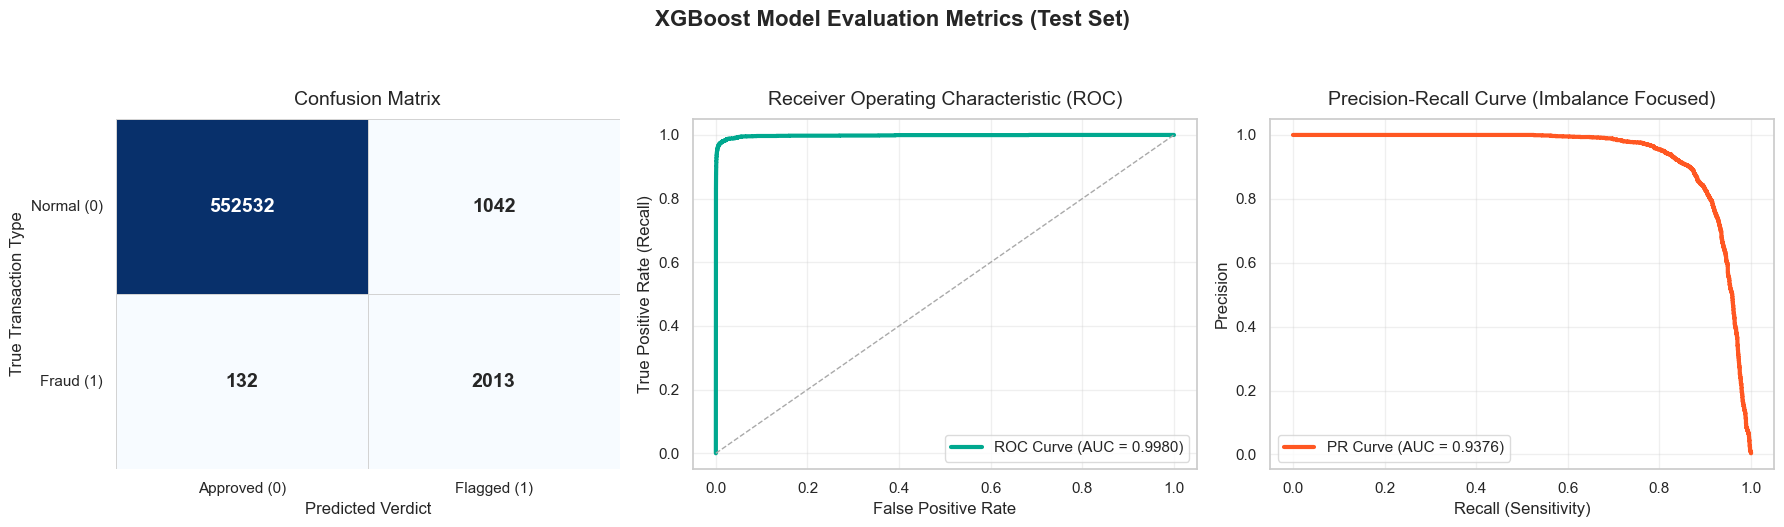

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve


sns.set_theme(style='whitegrid') 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost Model Evaluation Metrics (Test Set)', fontsize=16, fontweight='bold', y=1.05)

# Confusion Matrix
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], 
            annot_kws={'size': 14, 'weight': 'bold'}, linewidths=0.5, linecolor='lightgray')
axes[0].set_title('Confusion Matrix', fontsize=14, pad=10)
axes[0].set_xlabel('Predicted Verdict', fontsize=12)
axes[0].set_ylabel('True Transaction Type', fontsize=12)
axes[0].set_xticklabels(['Approved (0)', 'Flagged (1)'])
axes[0].set_yticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)

# ROC-AUC Curve 
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#00a88f', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})') # Darkened slightly for light background readability
axes[1].plot([0, 1], [0, 1], color='darkgray', lw=1, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=10)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].legend(loc='lower right', frameon=True, facecolor='white', edgecolor='lightgray') # White legend background
axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve 
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)
axes[2].plot(recall, precision, color='#ff5722', lw=3, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[2].set_title('Precision-Recall Curve (Imbalance Focused)', fontsize=14, pad=10)
axes[2].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].legend(loc='lower left', frameon=True, facecolor='white', edgecolor='lightgray') # White legend background
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('slide9_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


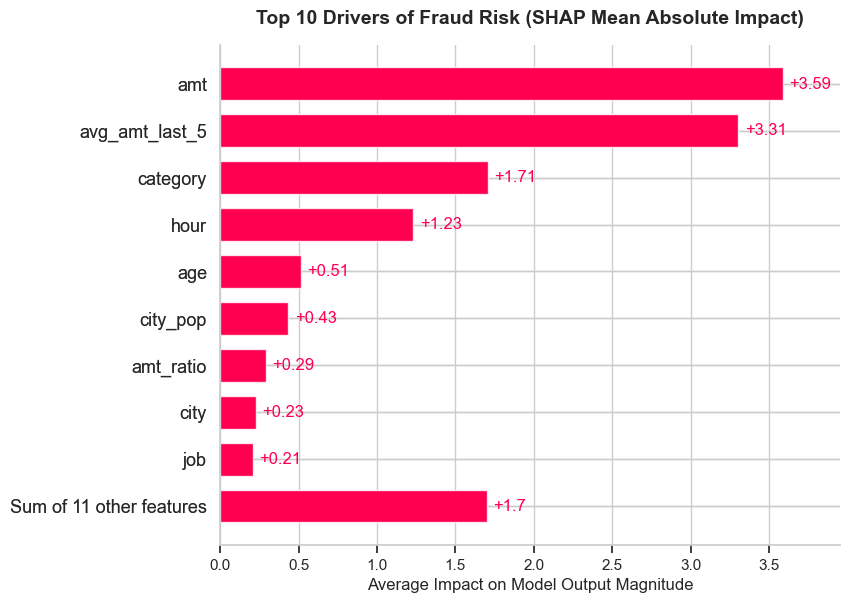

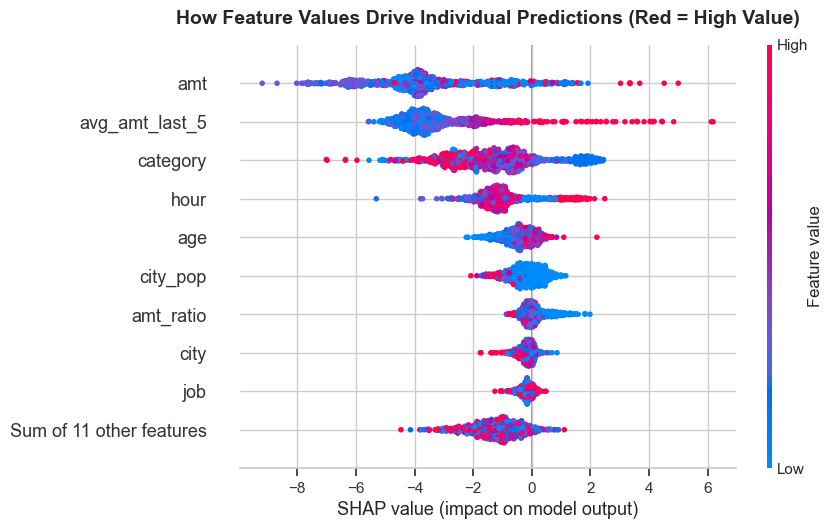

In [ ]:
import shap


sample_X = X_test.sample(n=1000, random_state=42)
shap_values = explainer(sample_X)


plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title('Top 10 Drivers of Fraud Risk (SHAP Mean Absolute Impact)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Impact on Model Output Magnitude', fontsize=12)

plt.savefig('slide5_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title('How Feature Values Drive Individual Predictions (Red = High Value)', fontsize=14, fontweight='bold', pad=15)

plt.savefig('slide8_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

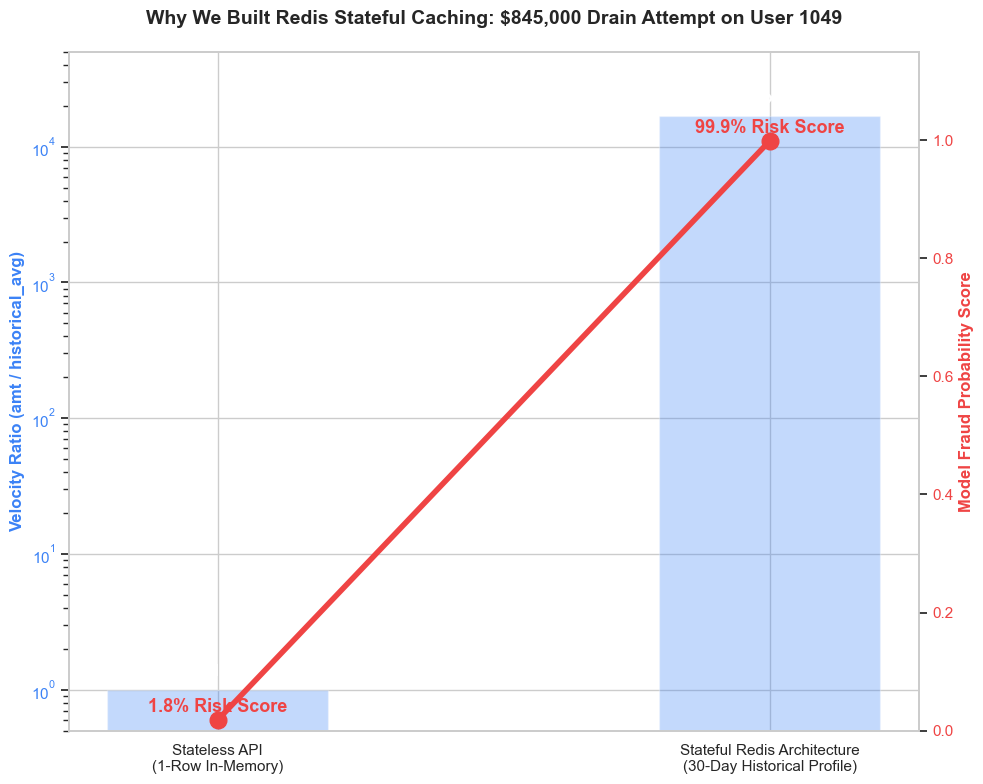

In [ ]:
import numpy as np


categories = ['Stateless API\n(1-Row In-Memory)', 'Stateful Redis Architecture\n(30-Day Historical Profile)']
ratios = [1.0, 16900.0] # 1.0x vs 16,900x risk spike
probabilities = [0.018, 0.999] # 1.8% vs 99.9% fraud score

fig, ax1 = plt.subplots(figsize=(10, 8))

color = '#3b82f6' # Blue
bars = ax1.bar(categories, ratios, color=color, alpha=0.3, width=0.4, label='Calculated Spending Ratio (amt_ratio)')
ax1.set_ylabel('Velocity Ratio (amt / historical_avg)', color=color, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log') # Log scale 
ax1.set_ylim(0.5, 50000)


for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height * 1.2,
             f'{height:,.1f}x Normal', ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)


ax2 = ax1.twinx()  
color = '#ef4444' # Red
ax2.plot(categories, probabilities, color=color, lw=4, marker='o', markersize=12, label='XGBoost Fraud Probability Score')
ax2.set_ylabel('Model Fraud Probability Score', color=color, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0.0, 1.15)


for i, txt in enumerate(probabilities):
    ax2.annotate(f'{txt*100:.1f}% Risk Score', (categories[i], probabilities[i]),
                 textcoords="offset points", xytext=(0, 6), ha='center', color='#ef4444', fontweight='bold', fontsize=13)

plt.title('Why We Built Redis Stateful Caching: $845,000 Drain Attempt on User 1049', fontsize=14, fontweight='bold', pad=20)
plt.grid(False)
plt.tight_layout()
plt.savefig('slide6_stateless_vs_stateful.png', dpi=300, bbox_inches='tight')
plt.show()

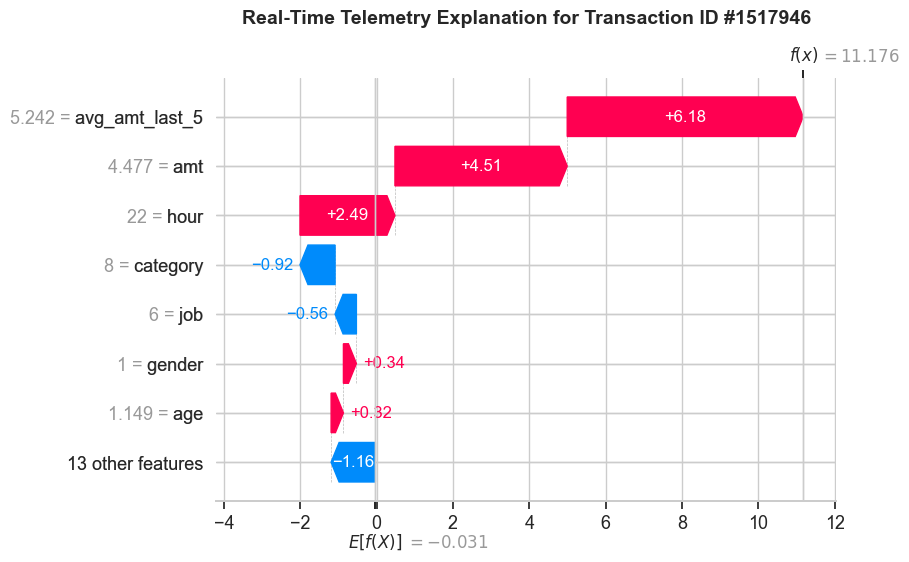

In [ ]:

fraud_idx = sample_X[y_test.loc[sample_X.index] == 1].index[0]
single_shap = explainer(sample_X.loc[[fraud_idx]])

plt.figure(figsize=(10, 5))
shap.plots.waterfall(single_shap[0], max_display=8, show=False)
plt.title(f'Real-Time Telemetry Explanation for Transaction ID #{fraud_idx}', fontsize=14, fontweight='bold', pad=15)
#plt.gcf().patch.set_facecolor('#0e1117')
plt.savefig('slide8_single_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()